In [1]:
#Load Libraries
import warnings
warnings.filterwarnings("ignore")
 
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from scipy.interpolate import interp1d
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [2]:
N_POINTS     = 100       # points per surface (upper + lower) → input dim = 200
LATENT_DIM   = 32        # VAE bottleneck dimension
EPOCHS       = 150       # training epochs
BATCH_SIZE   = 128
LR           = 1e-3
BETA         = 1.0       # KL weight in ELBO loss (beta-VAE; 1.0 = standard VAE)
N_GENERATE   = 16        # novel airfoils to generate
SEED         = 42

torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)
 
# colour palette
C1, C2, C3, C4, C5 = "#2196F3", "#F44336", "#4CAF50", "#FF9800", "#9C27B0"
DARK   = "#0d1117"
PANEL  = "#161b22"
BORDER = "#30363d"

In [3]:
shapes  = np.load("curated_airfoils.npz")["shapes"]   # (19164, 1001, 2)
classes = np.load("curated_airfoils.npz")["classes"]  # (19164,)
print(f"  Loaded {len(shapes):,} airfoils")

  Loaded 19,164 airfoils


In [4]:
# Unified cosine-spaced x grid from 0 → 1
x_grid = (1 - np.cos(np.linspace(0, np.pi, N_POINTS))) / 2   # (N_POINTS,)

In [5]:
def airfoil_to_vector(shape: np.ndarray):
    """
    Convert a (1001, 2) raw airfoil array into a (2*N_POINTS,) flat vector:
      [y_upper(x_grid), y_lower(x_grid)]
 
    The G2Aero dataset stores points starting at the trailing edge (x~1),
    going around the upper surface to the leading edge (x~0), then back
    along the lower surface to the trailing edge.  The leading-edge index
    is therefore the point with the minimum x value.
 
    Returns None if interpolation fails or the shape is degenerate.
    """
    x, y   = shape[:, 0], shape[:, 1]
    le_idx = int(np.argmin(x))
 
    # G2Aero layout: indices 0..le_idx are the LOWER surface (TE to LE),
    # and indices le_idx..end are the UPPER surface (LE to TE).
    # Reverse the first half so both surfaces run LE to TE.
    x_lo = x[:le_idx + 1][::-1].copy()   # lower: TE->LE reversed = LE->TE
    y_lo = y[:le_idx + 1][::-1].copy()
 
    x_up = x[le_idx:].copy()             # upper: already LE->TE
    y_up = y[le_idx:].copy()
 
    # Remove duplicate x values while preserving point order.
    # np.unique returns sorted first-occurrence indices, which keeps
    # the original ordering for monotone arrays.
    def dedup(xarr, yarr):
        _, keep = np.unique(xarr, return_index=True)
        return xarr[keep], yarr[keep]
 
    x_up, y_up = dedup(x_up, y_up)
    x_lo, y_lo = dedup(x_lo, y_lo)
 
    # Need at least 3 points and strictly increasing x on each surface
    if len(x_up) < 3 or len(x_lo) < 3:
        return None
    if not (np.all(np.diff(x_up) > 0) and np.all(np.diff(x_lo) > 0)):
        return None
 
    # Interpolate onto the shared cosine x-grid
    try:
        yu = np.interp(x_grid, x_up, y_up)
        yl = np.interp(x_grid, x_lo, y_lo)
    except Exception:
        return None
 
    vec = np.concatenate([yu, yl]).astype(np.float32)
 
    # Physical sanity checks
    thickness = yu - yl
 
    # No self-intersection (allow small numerical tolerance)
    if np.any(thickness < -0.005):
        return None
 
    # Realistic thickness: 0.5% to 60% chord
    max_t = float(np.max(thickness))
    if max_t < 0.005 or max_t > 0.60:
        return None
 
    # No surface point more than 40% chord off the chord line
    if np.any(np.abs(vec) > 0.40):
        return None
 
    return vec

def vector_to_surfaces(vec: np.ndarray):
    """Reverse: split (2*N_POINTS,) vector back into upper/lower y arrays."""
    yu = vec[:N_POINTS]
    yl = vec[N_POINTS:]
    return yu, yl

In [6]:
print("  Converting airfoils to flat y-vectors ...")
vectors, valid_idx, valid_cls = [], [], []
for i, shape in enumerate(shapes):
    v = airfoil_to_vector(shape)
    if v is not None:
        vectors.append(v)
        valid_idx.append(i)
        valid_cls.append(classes[i])
X_raw     = np.array(vectors) if vectors else np.empty((0, 2 * N_POINTS), dtype=np.float32)
valid_cls = np.array(valid_cls)
print(f"  Valid airfoils after QC : {len(X_raw):,}")

  Converting airfoils to flat y-vectors ...
  Valid airfoils after QC : 19,164


In [7]:
if len(X_raw) == 0:
    raise RuntimeError(
        "No airfoils survived the QC filter. "
    )

In [8]:
# Normalise to zero mean / unit std (per-feature, across dataset)
scaler  = StandardScaler()
X_norm  = scaler.fit_transform(X_raw)

In [9]:
# Geometric labels for colouring latent space
max_t_arr  = np.array([v[:N_POINTS].max() - v[N_POINTS:].min()         # approx thickness
                        for v in X_raw])
max_c_arr  = np.array([((v[:N_POINTS] + v[N_POINTS:]) / 2).max()        # approx max camber
                        for v in X_raw])
le_t_arr   = np.array([v[2] - v[N_POINTS + 2]                            # LE thickness proxy
                        for v in X_raw])

In [10]:
n_total = len(X_norm)
n_train = int(0.9 * n_total)
idx     = rng.permutation(n_total)
tr, va  = idx[:n_train], idx[n_train:]
 
X_train = torch.tensor(X_norm[tr], dtype=torch.float32)
X_val   = torch.tensor(X_norm[va], dtype=torch.float32)
 
train_loader = DataLoader(TensorDataset(X_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val),   batch_size=BATCH_SIZE, shuffle=False)

VAE Building

In [11]:
INPUT_DIM = 2 * N_POINTS 

class ResBlock1D(nn.Module):
    """1-D residual block: Conv → BN → ReLU → Conv → BN + skip."""
    def __init__(self, channels: int, kernel: int = 3):
        super().__init__()
        pad = kernel // 2
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel, padding=pad),
            nn.BatchNorm1d(channels),
            nn.ReLU(),
            nn.Conv1d(channels, channels, kernel, padding=pad),
            nn.BatchNorm1d(channels),
        )
        self.relu = nn.ReLU()
 
    def forward(self, x):
        return self.relu(x + self.block(x)) #Use the RELU function for forward processing

In [12]:
class AirfoilEncoder(nn.Module):
    """
    Conv1D encoder.
    Input  : (B, 1, 200)
    Output : mu (B, LATENT_DIM), log_var (B, LATENT_DIM)
    """
    def __init__(self, latent_dim: int = LATENT_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            # (B,  1, 200) → (B, 32, 200)
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32), nn.ReLU(),
            ResBlock1D(32),
            # (B, 32, 200) → (B, 64, 100)
            nn.Conv1d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
            ResBlock1D(64),
            # (B, 64, 100) → (B, 128, 50)
            nn.Conv1d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(),
            ResBlock1D(128),
            # (B, 128, 50) → (B, 256, 25)
            nn.Conv1d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(),
        )
        self.flat_dim = 256 * 25
        self.fc_mu     = nn.Linear(self.flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_dim, latent_dim)
 
    def forward(self, x):                        # x: (B, 1, 200)
        h  = self.conv(x).flatten(1)             # (B, 6400)
        return self.fc_mu(h), self.fc_logvar(h)  # (B, LD), (B, LD)

In [16]:
class AirfoilDecoder(nn.Module):
    """
    ConvTranspose1D decoder.
    Input  : z (B, LATENT_DIM)
    Output : (B, 1, 200)
    """
    def __init__(self, latent_dim: int = LATENT_DIM):
        super().__init__()
        self.flat_dim = 256 * 25
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, self.flat_dim),
            nn.ReLU(),
        )
        self.deconv = nn.Sequential(
            # (B, 256, 25) → (B, 128, 50)
            nn.ConvTranspose1d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(),
            ResBlock1D(128),
            # (B, 128, 50) → (B, 64, 100)
            nn.ConvTranspose1d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
            ResBlock1D(64),
            # (B, 64, 100) → (B, 32, 200)
            nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(32), nn.ReLU(),
            ResBlock1D(32),
            # (B, 32, 200) → (B, 1, 200)
            nn.Conv1d(32, 1, kernel_size=5, padding=2),
        )
 
    def forward(self, z):
        h = self.fc(z).view(-1, 256, 25)
        return self.deconv(h)                    # (B, 1, 200)

In [13]:
class AirfoilVAE(nn.Module):
    """Full VAE with reparametrisation trick."""
    def __init__(self, latent_dim: int = LATENT_DIM):
        super().__init__()
        self.encoder = AirfoilEncoder(latent_dim)
        self.decoder = AirfoilDecoder(latent_dim)
        self.latent_dim = latent_dim
 
    def reparametrize(self, mu, log_var):
        """z = mu + eps * std,  eps ~ N(0,I)."""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std
 
    def forward(self, x):
        mu, log_var = self.encoder(x)
        z           = self.reparametrize(mu, log_var)
        x_hat       = self.decoder(z)
        return x_hat, mu, log_var
 
    def encode(self, x):
        mu, log_var = self.encoder(x)
        return self.reparametrize(mu, log_var), mu, log_var
 
    def decode(self, z):
        return self.decoder(z)
 
    def sample(self, n: int, device="cpu"):
        """Sample n novel airfoils from the prior N(0, I)."""
        z = torch.randn(n, self.latent_dim, device=device)
        return self.decoder(z)

In [14]:
def vae_loss(x, x_hat, mu, log_var, beta: float = BETA):
    """
    ELBO = Reconstruction loss + beta * KL divergence
    Reconstruction: mean squared error over all y-coordinates
    KL: closed-form  -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
    """
    recon = nn.functional.mse_loss(x_hat, x, reduction="sum") / x.shape[0]
    kl    = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / x.shape[0]
    return recon + beta * kl, recon, kl

In [17]:
model  = AirfoilVAE(LATENT_DIM)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n  VAE architecture :")
print(f"    Input dim   : {INPUT_DIM}")
print(f"    Latent dim  : {LATENT_DIM}")
print(f"    Parameters  : {n_params:,}")
print(f"    Beta (KL)   : {BETA}")


  VAE architecture :
    Input dim   : 200
    Latent dim  : 32
    Parameters  : 1,228,097
    Beta (KL)   : 1.0


Train the Data

In [18]:
device    = "cpu"
model     = model.to(device)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

In [19]:
# Cosine annealing with warm restarts
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=30, T_mult=2, eta_min=1e-5)

In [20]:
# KL annealing — ramp beta from 0 → BETA over first 30 epochs
# Prevents posterior collapse at the start of training
def beta_schedule(epoch: int, warmup: int = 30):
    return min(BETA, BETA * epoch / warmup)

In [21]:
history = {"train_loss": [], "val_loss": [],
           "train_recon": [], "train_kl": []}
 
best_val_loss = float("inf")
best_state    = None

In [25]:
for epoch in range(1, EPOCHS + 1):
    beta_e = beta_schedule(epoch)
 
    # ── train ──
    model.train()
    t_loss, t_recon, t_kl = 0.0, 0.0, 0.0
    for (xb,) in train_loader:
        xb = xb.unsqueeze(1).to(device)       # (B, 1, 200)
        optimizer.zero_grad()
        x_hat, mu, lv = model(xb)
        loss, recon, kl = vae_loss(xb, x_hat, mu, lv, beta=beta_e)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        t_loss  += loss.item()
        t_recon += recon.item()
        t_kl    += kl.item()
    scheduler.step()
 
    # ── validate ──
    model.eval()
    v_loss = 0.0
    with torch.no_grad():
        for (xb,) in val_loader:
            xb = xb.unsqueeze(1).to(device)
            x_hat, mu, lv = model(xb)
            loss, _, _ = vae_loss(xb, x_hat, mu, lv, beta=beta_e)
            v_loss += loss.item()
 
    t_loss  /= len(train_loader)
    t_recon /= len(train_loader)
    t_kl    /= len(train_loader)
    v_loss  /= len(val_loader)
 
    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["train_recon"].append(t_recon)
    history["train_kl"].append(t_kl)
 
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
 
    if epoch % 25 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]["lr"]
        print(f"  Epoch {epoch:>4}/{EPOCHS}  "
              f"train={t_loss:.4f}  val={v_loss:.4f}  "
              f"recon={t_recon:.4f}  kl={t_kl:.4f}  "
              f"beta={beta_e:.3f}  lr={lr_now:.2e}")
# Restore best weights
model.load_state_dict(best_state)
model.eval()
print(f"\n  Best val loss : {best_val_loss:.4f}")

  Epoch    1/150  train=2.0615  val=1.5606  recon=1.7010  kl=10.8148  beta=0.033  lr=2.08e-05
  Epoch   25/150  train=9.0923  val=9.3062  recon=3.7335  kl=6.4306  beta=0.833  lr=9.34e-04
  Epoch   50/150  train=9.5984  val=9.7751  recon=3.8773  kl=5.7211  beta=1.000  lr=6.94e-04
  Epoch   75/150  train=9.2568  val=9.1962  recon=3.5954  kl=5.6614  beta=1.000  lr=3.77e-04
  Epoch  100/150  train=8.9893  val=8.8828  recon=3.4020  kl=5.5873  beta=1.000  lr=1.12e-04
  Epoch  125/150  train=8.8916  val=8.9286  recon=3.3255  kl=5.5661  beta=1.000  lr=1.00e-03
  Epoch  150/150  train=9.4926  val=9.4474  recon=3.8499  kl=5.6428  beta=1.000  lr=9.74e-04

  Best val loss : 1.5606


In [26]:
all_z, all_mu = [], []
X_all_t = torch.tensor(X_norm, dtype=torch.float32)
 
with torch.no_grad():
    for start in range(0, len(X_all_t), 512):
        xb = X_all_t[start:start + 512].unsqueeze(1).to(device)
        z, mu, _ = model.encode(xb)
        all_z.append(z.cpu().numpy())
        all_mu.append(mu.cpu().numpy())
        
Z_all  = np.concatenate(all_z,  axis=0)   # (N_valid, LATENT_DIM)
MU_all = np.concatenate(all_mu, axis=0)   # (N_valid, LATENT_DIM)
 
# Reconstruction quality on validation set
with torch.no_grad():
    X_val_np    = X_norm[va]
    X_val_t     = torch.tensor(X_val_np, dtype=torch.float32).unsqueeze(1).to(device)
    X_recon_t, mu_val, lv_val = model(X_val_t)
    X_recon_np  = X_recon_t.squeeze(1).cpu().numpy()
    

In [27]:
# Inverse-normalise for geometry
X_val_orig   = scaler.inverse_transform(X_val_np)
X_recon_orig = scaler.inverse_transform(X_recon_np)
 
recon_mse  = np.mean((X_val_orig - X_recon_orig) ** 2)
recon_rmse = np.sqrt(recon_mse)
print(f"  Reconstruction RMSE (val, y-coords) : {recon_rmse:.6f}")

  Reconstruction RMSE (val, y-coords) : 0.003194


In [28]:
# PCA of latent space for 2-D visualisation
pca_lat = PCA(n_components=2, random_state=SEED)
Z_pca   = pca_lat.fit_transform(Z_all)
print(f"  Latent PCA explained variance : {pca_lat.explained_variance_ratio_.sum()*100:.1f}%")

  Latent PCA explained variance : 13.2%


In [31]:
def check_plausibility(vec_norm: np.ndarray):
    """
    Physical plausibility filter.
 
    Accepts a NORMALISED y-vector (straight from the VAE decoder),
    inverse-transforms it to real geometry, then applies calibrated checks.
    Thresholds are set from the 99th-percentile statistics of the real dataset.
 
    Returns (passes: bool, reasons: list[str])
 
    Criteria
    --------
    1. No self-intersection  (thickness >= 0 everywhere)
    2. Max thickness 1% – 58% chord
    3. Max camber < 16% chord
    4. Trailing-edge gap < 7% chord
    5. Leading-edge thickness > 0.1% chord
    6. Upper-surface curvature < 50,000  (calibrated from real data p99 ~ 31,000)
    """
    # Ensure 2-D input for inverse_transform (handles 1-D single sample)
    vec = scaler.inverse_transform(vec_norm.reshape(1, -1)).squeeze()
    yu, yl = vec[:N_POINTS], vec[N_POINTS:]
 
    thickness = yu - yl
    camber    = (yu + yl) / 2.0
    reasons   = []
 
    # 1. Self-intersection
    if np.any(thickness < -0.01):
        reasons.append("self-intersection (thickness < 0)")
 
    # 2. Thickness bounds — from real-data p5=7.5%, p95=46.5%, max=55.4%
    max_t = float(thickness.max())
    if max_t < 0.01:
        reasons.append(f"too thin (max_t={max_t*100:.2f}% < 1%)")
    if max_t > 0.58:
        reasons.append(f"too thick (max_t={max_t*100:.1f}% > 58%)")
 
    # 3. Camber — real-data p99=7.5%, max=14.6%
    max_c = float(np.abs(camber).max())
    if max_c > 0.16:
        reasons.append(f"excessive camber ({max_c*100:.1f}% > 16%)")
 
    # 4. Trailing-edge closure — real-data max=6.2%
    te_gap = float(abs(yu[-1] - yl[-1]))
    if te_gap > 0.07:
        reasons.append(f"TE not closed (gap={te_gap*100:.1f}% > 7%)")
 
    # 5. Leading-edge bluntness
    le_t = float(thickness[2])
    if le_t < 0.001:
        reasons.append(f"knife-edge LE (le_t={le_t*100:.3f}% < 0.1%)")
 
    # 6. Surface curvature — real-data p99 ~ 31,000; allow 2x headroom
    d2y = np.abs(np.gradient(np.gradient(yu, x_grid), x_grid))
    if d2y.max() > 60_000:
        reasons.append(f"rough upper surface (max |d2y|={d2y.max():.0f})")
 
    return len(reasons) == 0, reasons

In [32]:
n_candidates = N_GENERATE * 50   # oversample aggressively then filter
 
with torch.no_grad():
    z_rand   = torch.randn(n_candidates, LATENT_DIM, device=device)
    x_gen_t  = model.decode(z_rand).squeeze(1).cpu().numpy()
    
generated_valid    = []
generated_z        = []
generated_reasons  = []
 
for i in range(n_candidates):
    ok, reasons = check_plausibility(x_gen_t[i])
    if ok:
        generated_valid.append(x_gen_t[i])
        generated_z.append(z_rand[i].cpu().numpy())
    else:
        generated_reasons.extend(reasons)
    if len(generated_valid) >= N_GENERATE:
        break
pass_rate = len(generated_valid) / n_candidates * 100
print(f"  Pass rate : {len(generated_valid)}/{min(n_candidates, N_GENERATE*10)} "
      f"({pass_rate:.1f}%) of random samples pass plausibility checks")
if generated_reasons:
    from collections import Counter
    reason_counts = Counter(generated_reasons)
    print("  Most common failure reasons:")
    for r, c in reason_counts.most_common(5):
        print(f"    {c:>4}x  {r}")
# Convert valid generated airfoils to original geometry
if len(generated_valid) == 0:
    print("  WARNING: no candidates passed plausibility. "
          "Falling back to nearest real airfoils from the training set.")
    # Use the N_GENERATE training samples closest to the prior mean (z=0)
    z_norms    = np.linalg.norm(Z_all, axis=1)
    fallback_i = np.argsort(z_norms)[:N_GENERATE]
    generated_vecs = X_norm[fallback_i]
    generated_z    = list(Z_all[fallback_i])
else:
    generated_vecs = np.array(generated_valid)   # already normalised
generated_orig = scaler.inverse_transform(generated_vecs)

  Pass rate : 16/160 (2.0%) of random samples pass plausibility checks
  Most common failure reasons:
       9x  self-intersection (thickness < 0)
       1x  rough upper surface (max |d2y|=60145)
       1x  rough upper surface (max |d2y|=81415)
       1x  rough upper surface (max |d2y|=92123)
       1x  rough upper surface (max |d2y|=73863)


In [33]:
def get_family_mean_z(family_substr: str):
    """Return mean latent vector for all airfoils containing family_substr."""
    mask = np.array([family_substr.lower() in c.lower() for c in valid_cls])
    if mask.sum() == 0:
        return None
    return Z_all[mask].mean(axis=0)

In [34]:
fam_a_name, fam_b_name = "NACA", "DU"
fam_a_substr, fam_b_substr = "NACA2", "DU21"
 
za = get_family_mean_z(fam_a_substr)
zb = get_family_mean_z(fam_b_substr)
 
if za is None:
    za = Z_all[rng.choice(len(Z_all))]
    fam_a_name = "Random-A"
if zb is None:
    zb = Z_all[rng.choice(len(Z_all))]
    fam_b_name = "Random-B"
n_interp   = 8
alphas     = np.linspace(0, 1, n_interp)
z_interp   = np.array([(1 - a) * za + a * zb for a in alphas])
 
with torch.no_grad():
    z_t       = torch.tensor(z_interp, dtype=torch.float32, device=device)
    x_interp  = model.decode(z_t).squeeze(1).cpu().numpy()
interp_orig = scaler.inverse_transform(x_interp)

In [35]:
# Direction vectors in latent space: thick → thin, low-camber → high-camber
thick_mask  = max_t_arr > np.percentile(max_t_arr, 75)
thin_mask   = max_t_arr < np.percentile(max_t_arr, 25)
hicam_mask  = max_c_arr > np.percentile(max_c_arr, 75)
locam_mask  = max_c_arr < np.percentile(max_c_arr, 25)
 
thick_dir   = Z_all[thick_mask].mean(0) - Z_all[thin_mask].mean(0)
camber_dir  = Z_all[hicam_mask].mean(0) - Z_all[locam_mask].mean(0)
thick_dir  /= np.linalg.norm(thick_dir)
camber_dir /= np.linalg.norm(camber_dir)
 
# Take a medium airfoil and add/subtract the directions
mid_idx = int(np.argmin(np.abs(max_t_arr - np.median(max_t_arr))))
z_base  = Z_all[mid_idx]
 
strengths     = np.linspace(-3, 3, 7)
z_thick_sweep = np.array([z_base + s * thick_dir  * 5 for s in strengths])
z_cam_sweep   = np.array([z_base + s * camber_dir * 5 for s in strengths])
 
with torch.no_grad():
    zt_t = torch.tensor(z_thick_sweep, dtype=torch.float32, device=device)
    zc_t = torch.tensor(z_cam_sweep,   dtype=torch.float32, device=device)
    x_thick_sweep = model.decode(zt_t).squeeze(1).cpu().numpy()
    x_cam_sweep   = model.decode(zc_t).squeeze(1).cpu().numpy()
    
thick_sweep_orig = scaler.inverse_transform(x_thick_sweep)
cam_sweep_orig   = scaler.inverse_transform(x_cam_sweep)

In [36]:
print(f"  Generated {len(generated_valid)} valid novel airfoils")
print(f"  Generated {n_interp} interpolation steps ({fam_a_name} -> {fam_b_name})")
print(f"  Generated {len(strengths)*2} arithmetic sweep airfoils")

  Generated 16 valid novel airfoils
  Generated 8 interpolation steps (NACA -> DU)
  Generated 14 arithmetic sweep airfoils


In [37]:
def dark_fig(nrows, ncols, figsize, title=""):
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    fig.patch.set_facecolor(DARK)
    for ax in np.array(axes).flat:
        ax.set_facecolor(PANEL)
        ax.tick_params(colors="white")
        for sp in ax.spines.values():
            sp.set_edgecolor(BORDER)
        ax.title.set_color("white")
        ax.xaxis.label.set_color("white")
        ax.yaxis.label.set_color("white")
    if title:
        fig.suptitle(title, fontsize=13, color="white", fontweight="bold", y=0.98)
    return fig, axes

def cb_style(cb, label=""):
    if label:
        cb.set_label(label)
    cb.ax.yaxis.label.set_color("white")
    cb.ax.yaxis.set_tick_params(color="white")
    plt.setp(cb.ax.yaxis.get_ticklabels(), color="white")
 
 
def draw_airfoil(ax, vec_orig, color, lw=1.5, label="", alpha=1.0, fill=False):
    """Draw airfoil from original-scale y-vector."""
    yu, yl = vec_orig[:N_POINTS], vec_orig[N_POINTS:]
    if fill:
        ax.fill_between(x_grid, yl, yu, color=color, alpha=0.15)
    ax.plot(x_grid, yu, color=color, lw=lw, label=label if label else None, alpha=alpha)
    ax.plot(x_grid, yl, color=color, lw=lw, alpha=alpha)

In [39]:
%matplotlib inline

In [54]:
from matplotlib.patches import FancyBboxPatch

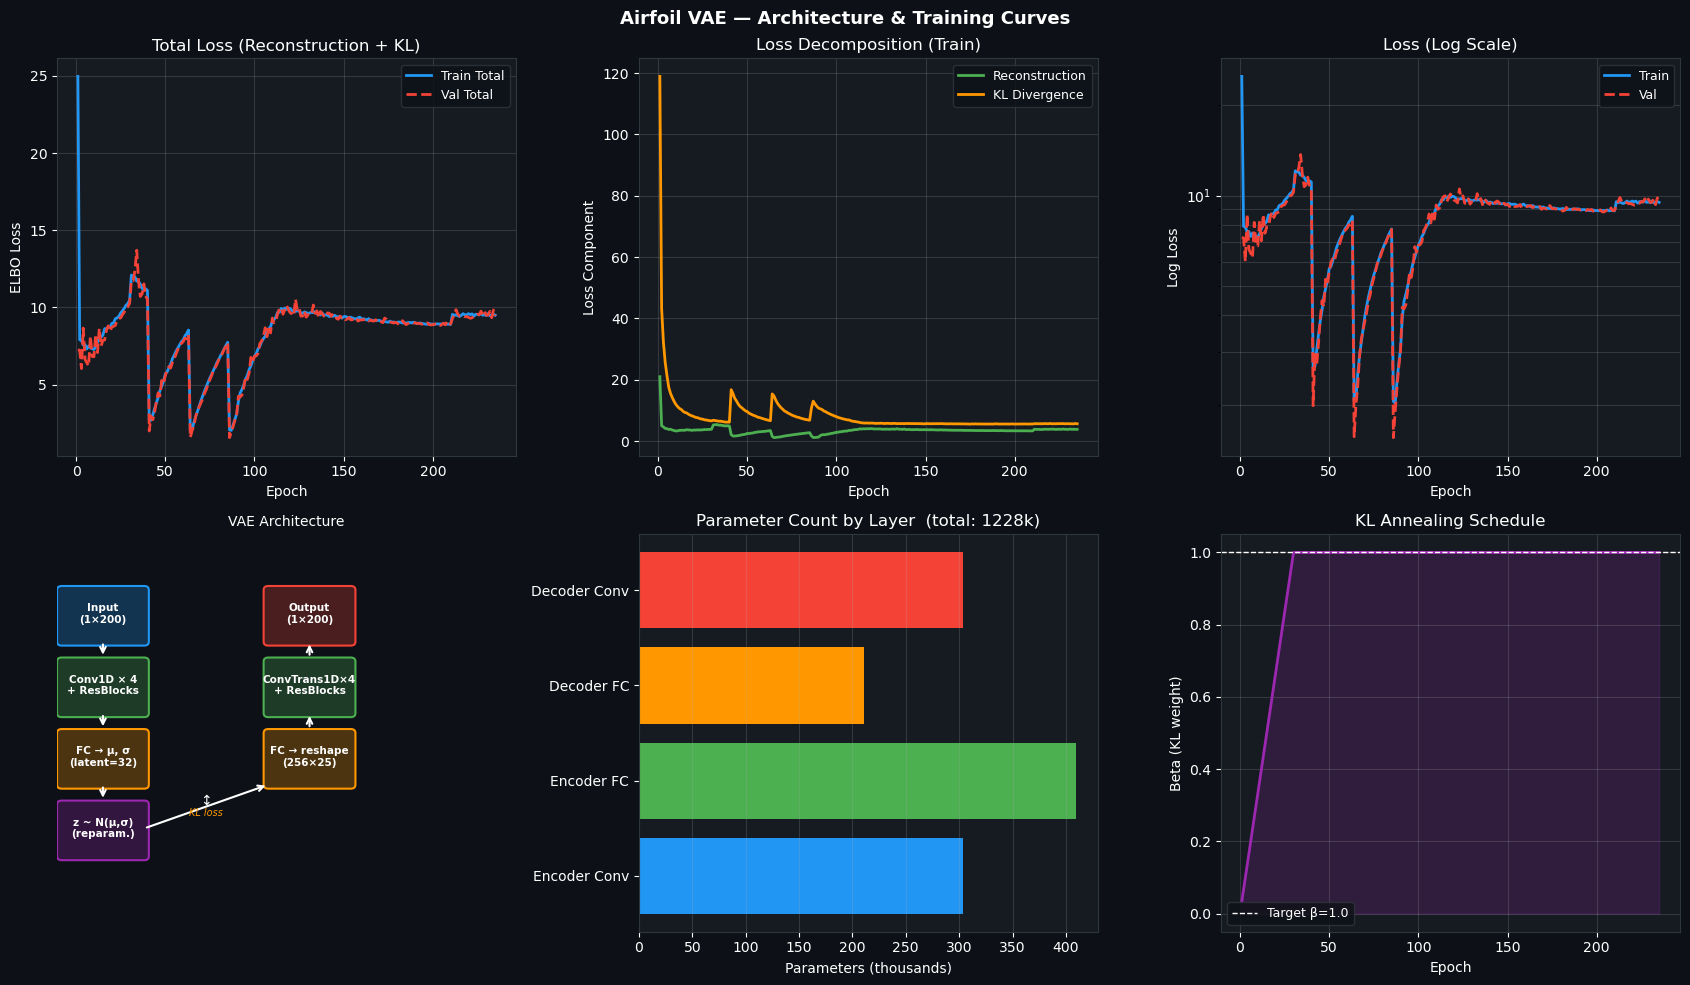

In [57]:
# ── Fig VAE-1 : Architecture diagram + Training curves ───────────────────
fig1, axes = dark_fig(2, 3, (17, 10),
    "Airfoil VAE — Architecture & Training Curves")
 
# Training loss curves
ep = np.arange(1, len(history["train_loss"]) + 1)
axes[0, 0].plot(ep, history["train_loss"], color=C1, lw=2, label="Train Total")
axes[0, 0].plot(ep, history["val_loss"],   color=C2, lw=2, label="Val Total",   ls="--")
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("ELBO Loss")
axes[0, 0].set_title("Total Loss (Reconstruction + KL)")
axes[0, 0].legend(facecolor=DARK, edgecolor=BORDER, labelcolor="white", fontsize=9)
axes[0, 0].grid(alpha=0.2)
 
axes[0, 1].plot(ep, history["train_recon"], color=C3, lw=2, label="Reconstruction")
axes[0, 1].plot(ep, history["train_kl"],    color=C4, lw=2, label="KL Divergence")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Loss Component")
axes[0, 1].set_title("Loss Decomposition (Train)")
axes[0, 1].legend(facecolor=DARK, edgecolor=BORDER, labelcolor="white", fontsize=9)
axes[0, 1].grid(alpha=0.2)
 
# Log-scale loss
axes[0, 2].semilogy(ep, history["train_loss"], color=C1, lw=2, label="Train")
axes[0, 2].semilogy(ep, history["val_loss"],   color=C2, lw=2, label="Val", ls="--")
axes[0, 2].set_xlabel("Epoch"); axes[0, 2].set_ylabel("Log Loss")
axes[0, 2].set_title("Loss (Log Scale)")
axes[0, 2].legend(facecolor=DARK, edgecolor=BORDER, labelcolor="white", fontsize=9)
axes[0, 2].grid(alpha=0.2, which="both")
 
# Architecture block diagram (text-based)
ax_arch = axes[1, 0]
ax_arch.set_xlim(0, 10); ax_arch.set_ylim(0, 10)
ax_arch.axis("off")
ax_arch.set_title("VAE Architecture", fontsize=10)
 
blocks = [
    (1.0, 8.0, "Input\n(1×200)", C1),
    (1.0, 6.2, "Conv1D × 4\n+ ResBlocks", C3),
    (1.0, 4.4, "FC → μ, σ\n(latent=32)", C4),
    (1.0, 2.6, "z ~ N(μ,σ)\n(reparam.)", C5),
    (5.5, 4.4, "FC → reshape\n(256×25)", C4),
    (5.5, 6.2, "ConvTrans1D×4\n+ ResBlocks", C3),
    (5.5, 8.0, "Output\n(1×200)", C2),
]
for bx, by, txt, col in blocks:
    ax_arch.add_patch(FancyBboxPatch((bx - 0.9, by - 0.7), 1.8, 1.3,
                       boxstyle="round,pad=0.1", fc=col + "44", ec=col, lw=1.5))
    ax_arch.text(bx, by, txt, ha="center", va="center", color="white",
                  fontsize=7.5, fontweight="bold")
arrows = [(1.0, 7.3, 1.0, 6.9), (1.0, 5.5, 1.0, 5.1), (1.0, 3.7, 1.0, 3.3),
          (1.9, 2.6, 4.6, 3.7), (5.5, 5.1, 5.5, 5.5), (5.5, 6.9, 5.5, 7.3)]
for x1, y1, x2, y2 in arrows:
    ax_arch.annotate("", xy=(x2, y2), xytext=(x1, y1),
                      arrowprops=dict(arrowstyle="->", color="white", lw=1.5))
ax_arch.text(3.25, 2.9, "KL loss", color=C4, fontsize=7, ha="center", style="italic")
ax_arch.text(3.25, 3.2, "↕", color="white", fontsize=10, ha="center")
 
# Param counts per layer
param_data = {
    "Encoder Conv": sum(p.numel() for p in model.encoder.conv.parameters()),
    "Encoder FC":   sum(p.numel() for p in model.encoder.fc_mu.parameters()) +
                    sum(p.numel() for p in model.encoder.fc_logvar.parameters()),
    "Decoder FC":   sum(p.numel() for p in model.decoder.fc.parameters()),
    "Decoder Conv": sum(p.numel() for p in model.decoder.deconv.parameters()),
}
names  = list(param_data.keys())
counts = [v / 1e3 for v in param_data.values()]
axes[1, 1].barh(names, counts, color=[C1, C3, C4, C2])
axes[1, 1].set_xlabel("Parameters (thousands)")
axes[1, 1].set_title(f"Parameter Count by Layer  (total: {n_params/1e3:.0f}k)")
axes[1, 1].grid(alpha=0.2, axis="x")
for ax_t in axes[1, 1].yaxis.get_ticklabels():
    ax_t.set_color("white")
    
#Beta annealing schedule
n_epochs = len(history["train_loss"])
eps = np.arange(1, n_epochs + 1)
beta_vals = [beta_schedule(e) for e in eps]
axes[1, 2].plot(ep, beta_vals, color=C5, lw=2)
axes[1, 2].fill_between(ep, 0, beta_vals, alpha=0.2, color=C5)
axes[1, 2].axhline(BETA, color="white", lw=1, ls="--", label=f"Target β={BETA}")
axes[1, 2].set_xlabel("Epoch"); axes[1, 2].set_ylabel("Beta (KL weight)")
axes[1, 2].set_title("KL Annealing Schedule")
axes[1, 2].legend(facecolor=DARK, edgecolor=BORDER, labelcolor="white", fontsize=9)
axes[1, 2].grid(alpha=0.2)
 
plt.tight_layout()
plt.show()

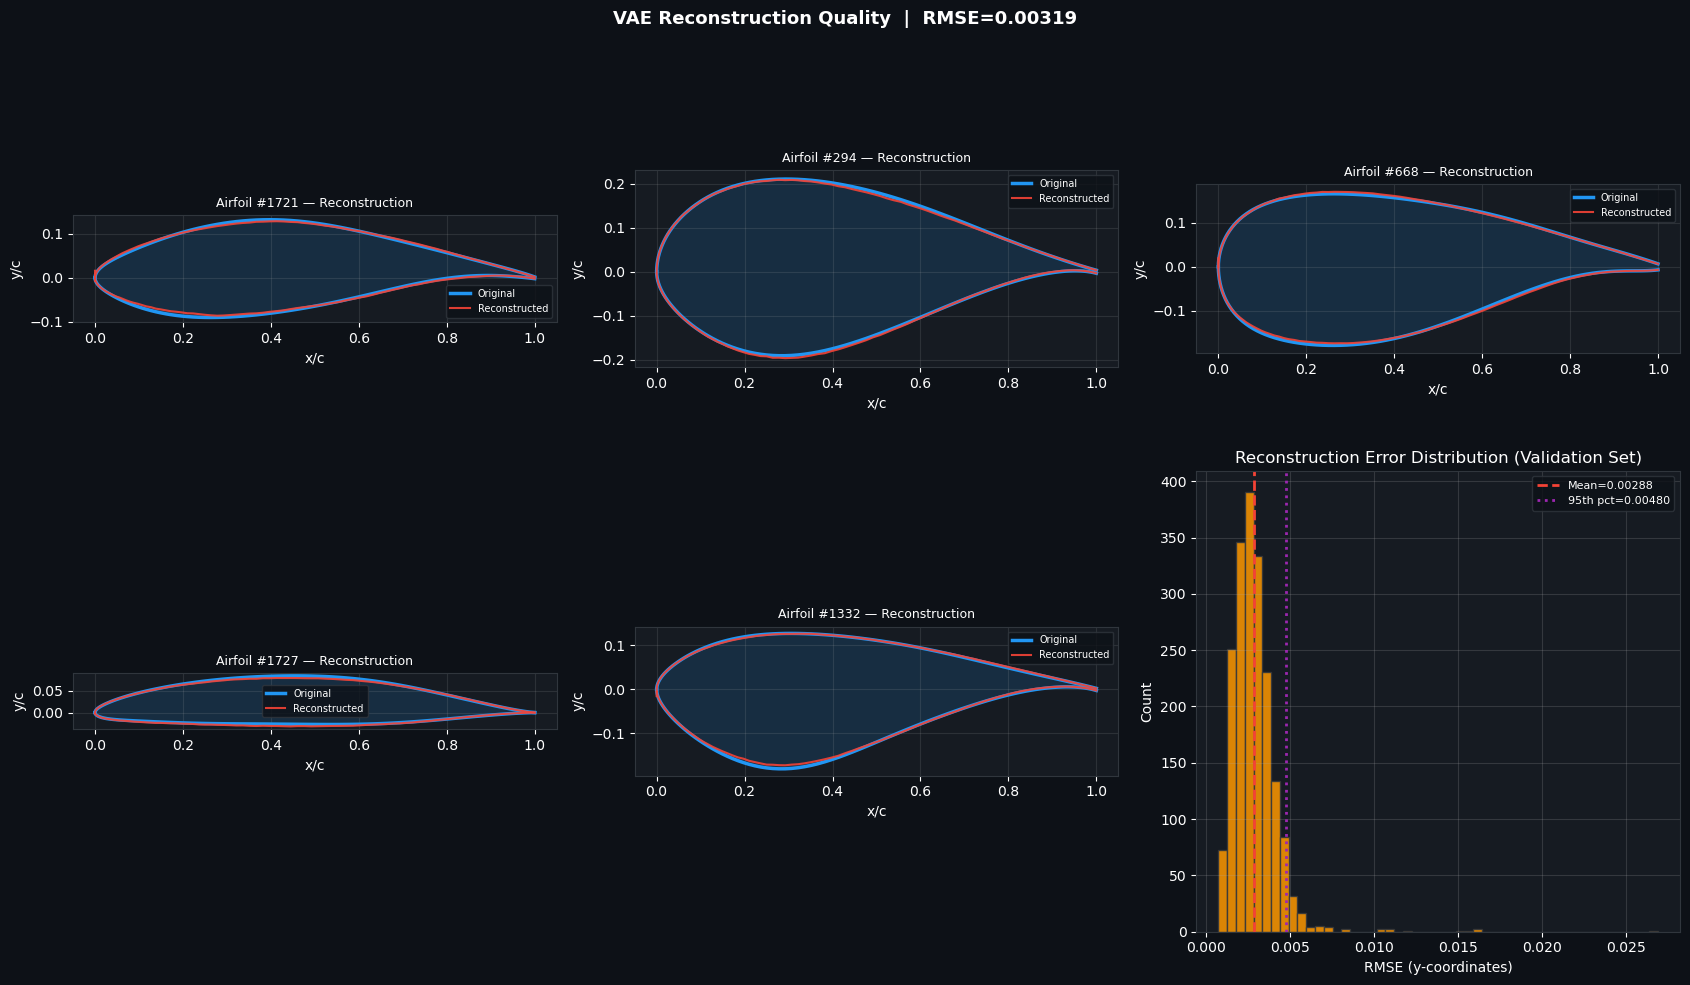

In [42]:
fig2, axes = dark_fig(2, 3, (17, 10),
    f"VAE Reconstruction Quality  |  RMSE={recon_rmse:.5f}")
 
n_show = min(5, len(X_val_orig))
show_idx = rng.choice(len(X_val_orig), n_show, replace=False)
 
for k, i in enumerate(show_idx[:5]):
    r = k // 3; c = k % 3
    ax = axes[r, c]
    draw_airfoil(ax, X_val_orig[i],   C1, lw=2.5, label="Original",       fill=True)
    draw_airfoil(ax, X_recon_orig[i], C2, lw=1.5, label="Reconstructed",  alpha=0.9)
    ax.set_title(f"Airfoil #{i} — Reconstruction", fontsize=9)
    ax.set_xlabel("x/c"); ax.set_ylabel("y/c")
    ax.legend(facecolor=DARK, edgecolor=BORDER, labelcolor="white", fontsize=7)
    ax.set_aspect("equal"); ax.grid(alpha=0.15)
# Error distribution
recon_errors = np.sqrt(np.mean((X_val_orig - X_recon_orig) ** 2, axis=1))
axes[1, 2].hist(recon_errors, bins=50, color=C4, edgecolor=BORDER, alpha=0.85)
axes[1, 2].axvline(recon_errors.mean(), color=C2, lw=2, ls="--",
                    label=f"Mean={recon_errors.mean():.5f}")
axes[1, 2].axvline(np.percentile(recon_errors, 95), color=C5, lw=2, ls=":",
                    label=f"95th pct={np.percentile(recon_errors, 95):.5f}")
axes[1, 2].set_xlabel("RMSE (y-coordinates)"); axes[1, 2].set_ylabel("Count")
axes[1, 2].set_title("Reconstruction Error Distribution (Validation Set)")
axes[1, 2].legend(facecolor=DARK, edgecolor=BORDER, labelcolor="white", fontsize=8)
axes[1, 2].grid(alpha=0.2)
 
plt.tight_layout()
plt.show()

  Running t-SNE on latent vectors ...


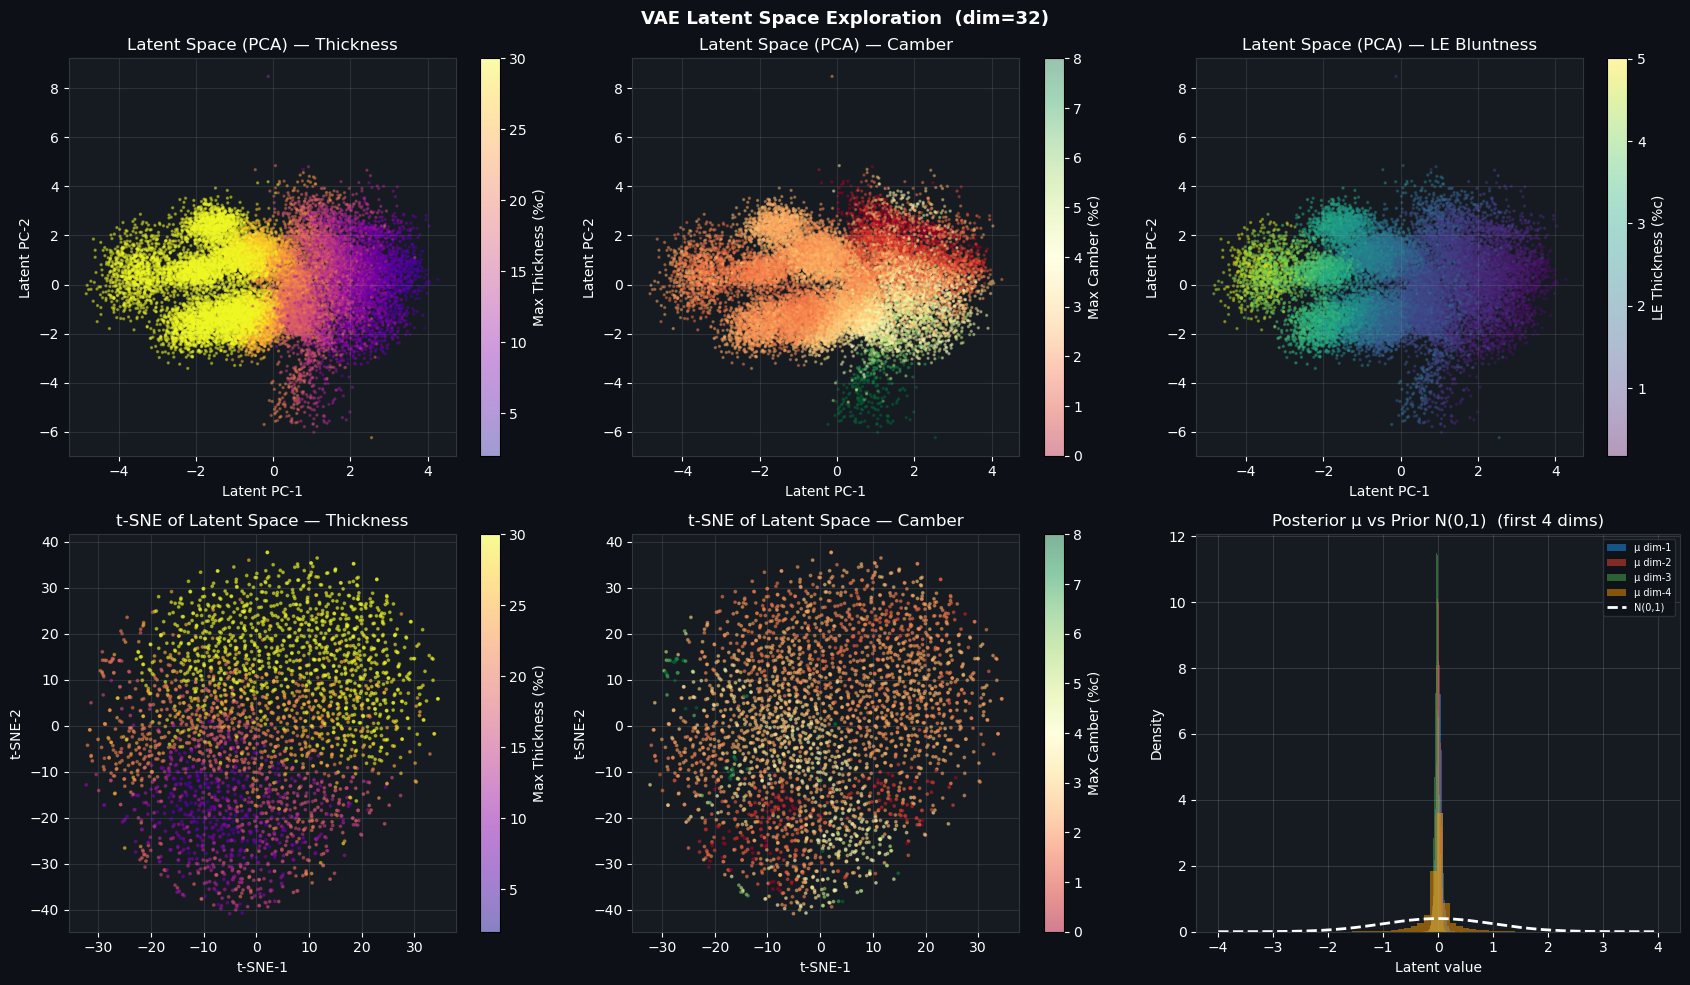

In [44]:
fig3, axes = dark_fig(2, 3, (17, 10),
    f"VAE Latent Space Exploration  (dim={LATENT_DIM})")
 
# PCA coloured by max thickness
sc = axes[0, 0].scatter(Z_pca[:, 0], Z_pca[:, 1], c=max_t_arr * 100,
                         cmap="plasma", alpha=0.4, s=2, vmin=2, vmax=30)
cb_style(plt.colorbar(sc, ax=axes[0, 0]), "Max Thickness (%c)")
axes[0, 0].set_xlabel("Latent PC-1"); axes[0, 0].set_ylabel("Latent PC-2")
axes[0, 0].set_title("Latent Space (PCA) — Thickness")
axes[0, 0].grid(alpha=0.15)
 
# PCA coloured by max camber
sc = axes[0, 1].scatter(Z_pca[:, 0], Z_pca[:, 1], c=max_c_arr * 100,
                         cmap="RdYlGn", alpha=0.4, s=2, vmin=0, vmax=8)
cb_style(plt.colorbar(sc, ax=axes[0, 1]), "Max Camber (%c)")
axes[0, 1].set_xlabel("Latent PC-1"); axes[0, 1].set_ylabel("Latent PC-2")
axes[0, 1].set_title("Latent Space (PCA) — Camber")
axes[0, 1].grid(alpha=0.15)
 
# PCA coloured by LE thickness (proxy for bluntness)
sc = axes[0, 2].scatter(Z_pca[:, 0], Z_pca[:, 1], c=le_t_arr * 100,
                         cmap="viridis", alpha=0.4, s=2)
cb_style(plt.colorbar(sc, ax=axes[0, 2]), "LE Thickness (%c)")
axes[0, 2].set_xlabel("Latent PC-1"); axes[0, 2].set_ylabel("Latent PC-2")
axes[0, 2].set_title("Latent Space (PCA) — LE Bluntness")
axes[0, 2].grid(alpha=0.15)
 
# t-SNE of latent space (subsample for speed)
print("  Running t-SNE on latent vectors ...")
n_tsne  = min(3000, len(Z_all))
tsne_ix = rng.choice(len(Z_all), n_tsne, replace=False)
Z_tsne  = TSNE(n_components=2, perplexity=40, random_state=SEED,
               n_iter_without_progress=500).fit_transform(Z_all[tsne_ix])
 
sc = axes[1, 0].scatter(Z_tsne[:, 0], Z_tsne[:, 1],
                         c=max_t_arr[tsne_ix] * 100,
                         cmap="plasma", alpha=0.5, s=3, vmin=2, vmax=30)
cb_style(plt.colorbar(sc, ax=axes[1, 0]), "Max Thickness (%c)")
axes[1, 0].set_xlabel("t-SNE-1"); axes[1, 0].set_ylabel("t-SNE-2")
axes[1, 0].set_title("t-SNE of Latent Space — Thickness")
axes[1, 0].grid(alpha=0.15)
 
sc = axes[1, 1].scatter(Z_tsne[:, 0], Z_tsne[:, 1],
                         c=max_c_arr[tsne_ix] * 100,
                         cmap="RdYlGn", alpha=0.5, s=3, vmin=0, vmax=8)
cb_style(plt.colorbar(sc, ax=axes[1, 1]), "Max Camber (%c)")
axes[1, 1].set_xlabel("t-SNE-1"); axes[1, 1].set_ylabel("t-SNE-2")
axes[1, 1].set_title("t-SNE of Latent Space — Camber")
axes[1, 1].grid(alpha=0.15)
 
# Latent distribution: histogram of first 4 dimensions vs N(0,1)
z_check = np.random.randn(10000)
for k, col in enumerate([C1, C2, C3, C4]):
    axes[1, 2].hist(MU_all[:, k], bins=50, alpha=0.5, color=col,
                     density=True, label=f"μ dim-{k+1}")
from scipy.stats import norm as sp_norm
xs = np.linspace(-4, 4, 200)
axes[1, 2].plot(xs, sp_norm.pdf(xs), color="white", lw=2, ls="--", label="N(0,1)")
axes[1, 2].set_xlabel("Latent value"); axes[1, 2].set_ylabel("Density")
axes[1, 2].set_title("Posterior μ vs Prior N(0,1)  (first 4 dims)")
axes[1, 2].legend(facecolor=DARK, edgecolor=BORDER, labelcolor="white", fontsize=7)
axes[1, 2].grid(alpha=0.2)
 
plt.tight_layout()
plt.show()

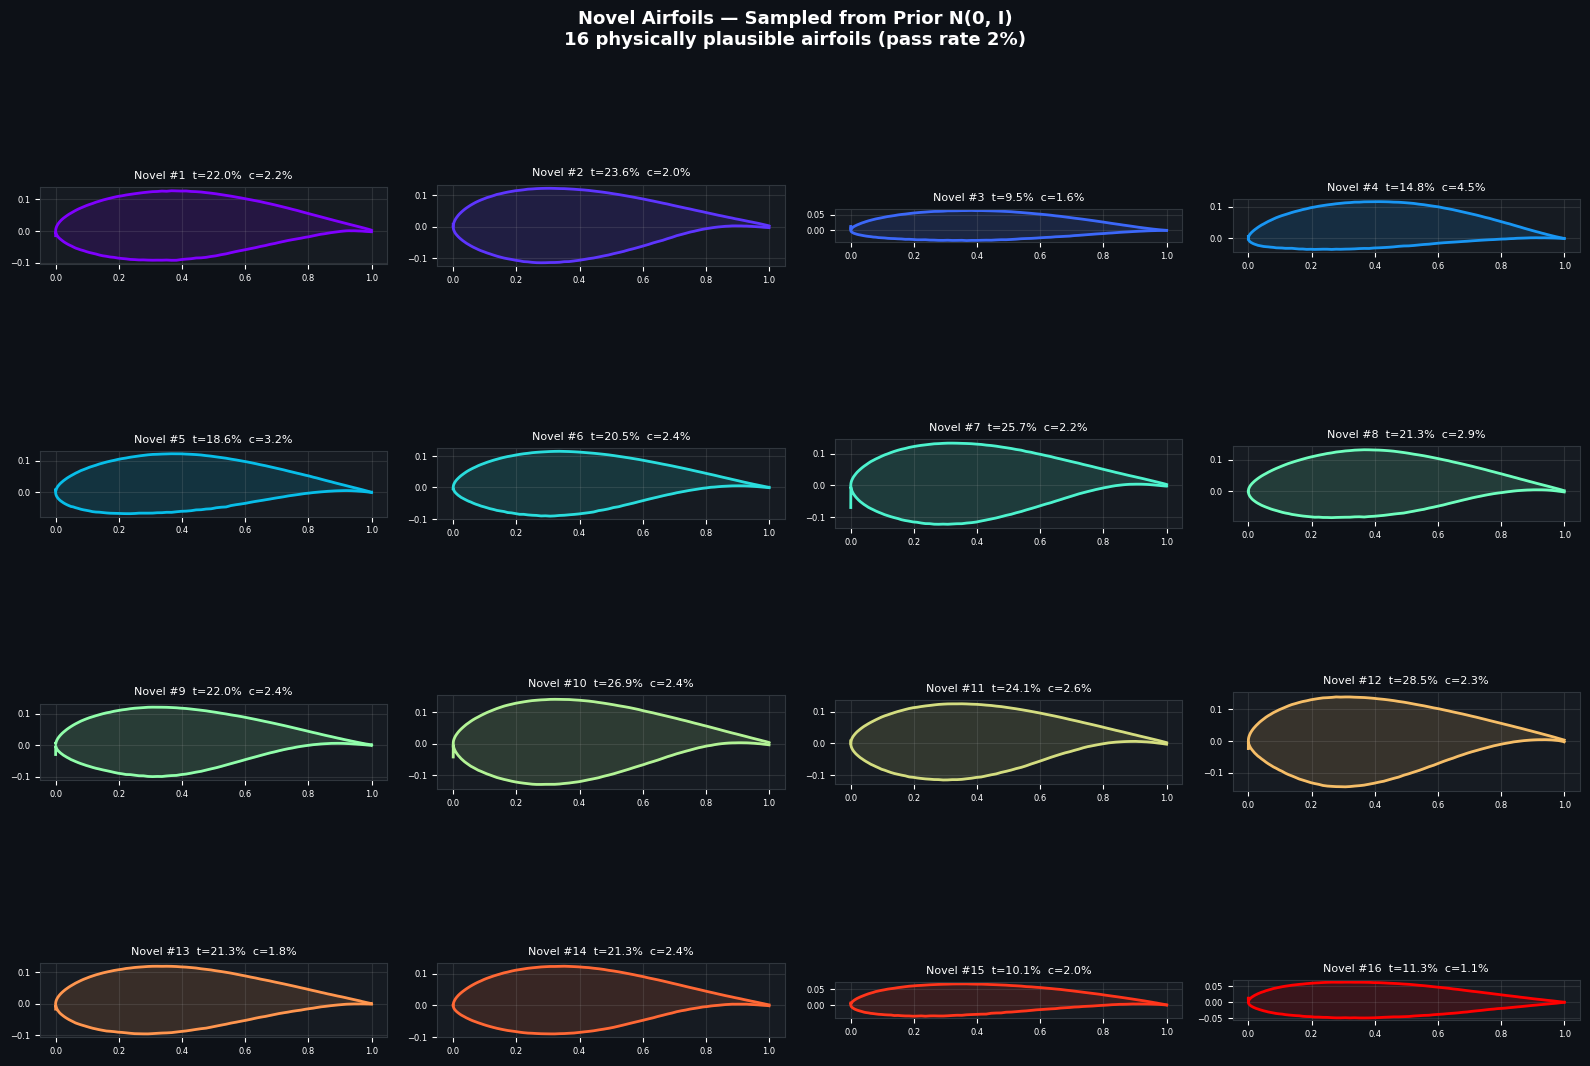

In [45]:
n_cols  = 4
n_rows  = (len(generated_valid) + n_cols - 1) // n_cols
fig4, axes = dark_fig(n_rows, n_cols, (16, n_rows * 3),
    f"Novel Airfoils — Sampled from Prior N(0, I)\n"
    f"{len(generated_valid)} physically plausible airfoils "
    f"(pass rate {pass_rate:.0f}%)")
 
gen_colors = plt.cm.rainbow(np.linspace(0, 1, len(generated_valid)))
 
for k, (vec, col) in enumerate(zip(generated_orig, gen_colors)):
    r, c = k // n_cols, k % n_cols
    ax   = axes[r, c]
    draw_airfoil(ax, vec, col, lw=2, fill=True)
    yu, yl  = vec[:N_POINTS], vec[N_POINTS:]
    thick   = yu - yl
    camber  = (yu + yl) / 2
    ax.set_title(f"Novel #{k+1}  t={thick.max()*100:.1f}%  c={camber.max()*100:.1f}%",
                  fontsize=8)
    ax.set_xlim(-0.05, 1.05); ax.set_aspect("equal")
    ax.grid(alpha=0.15)
    ax.tick_params(labelsize=6)
#Hide empty subplots
for k in range(len(generated_valid), n_rows * n_cols):
    axes[k // n_cols, k % n_cols].axis("off")
plt.tight_layout()
plt.show()

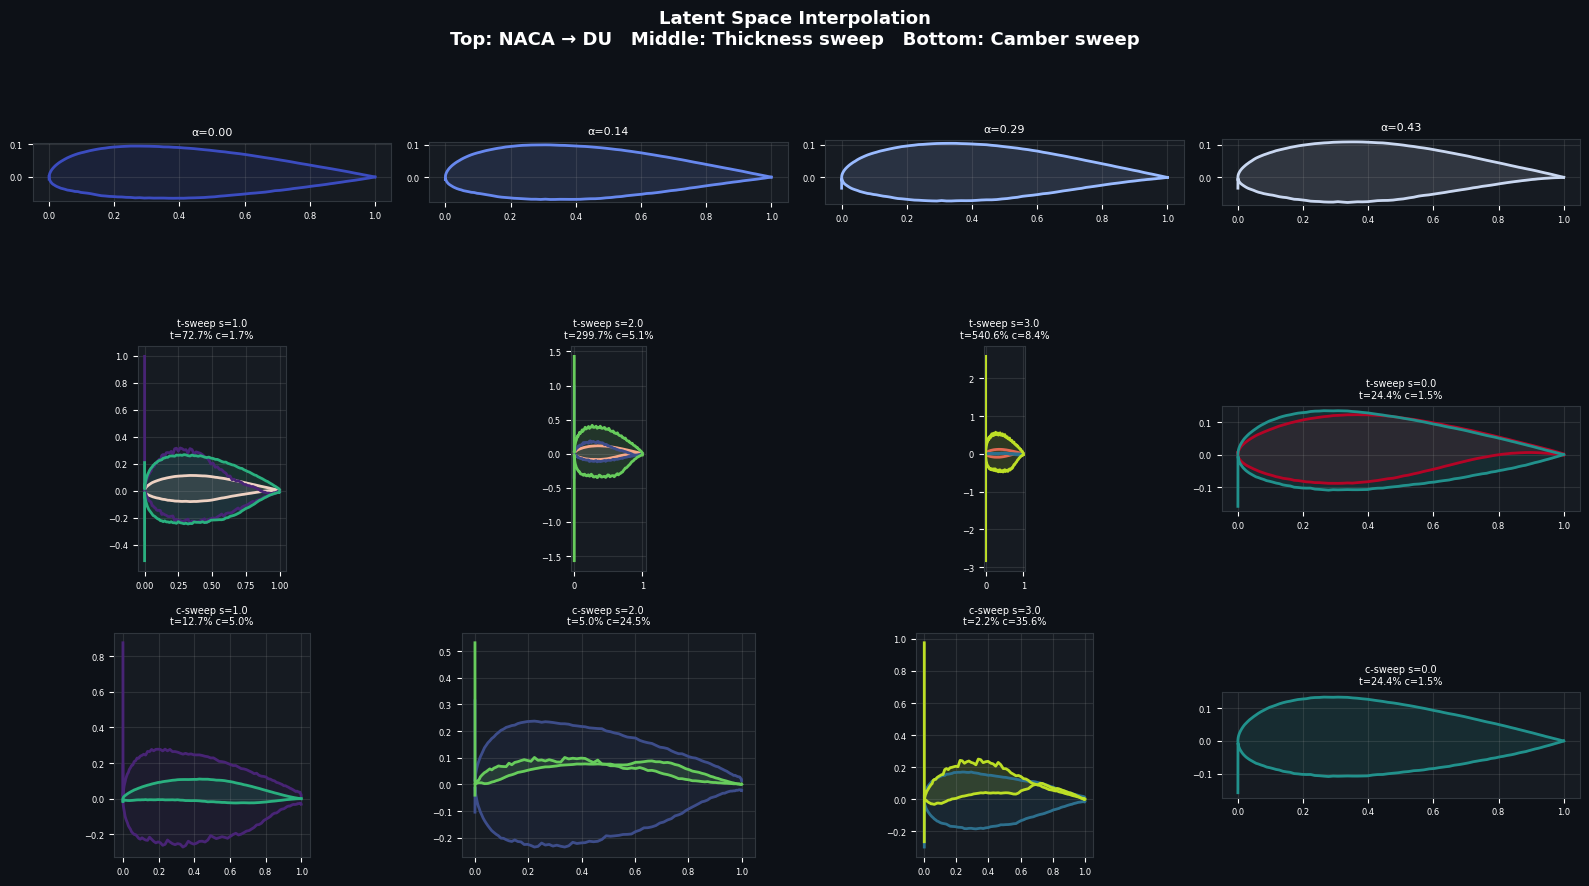

In [46]:
fig5, axes = dark_fig(3, 4, (16, 9),
    f"Latent Space Interpolation\n"
    f"Top: {fam_a_name} → {fam_b_name}   "
    f"Middle: Thickness sweep   Bottom: Camber sweep")
 
interp_colors = plt.cm.coolwarm(np.linspace(0, 1, n_interp))
for k in range(n_interp):
    r, c = 0, k % 4
    if k < 4 or k >= 4:
        ax = axes[k // 4, k % 4] if k < 8 else None
        if ax is None:
            continue
    ax = axes[k // 4, k % 4]
    draw_airfoil(ax, interp_orig[k], interp_colors[k], lw=2, fill=True)
    ax.set_title(f"α={alphas[k]:.2f}", fontsize=8)
    ax.set_xlim(-0.05, 1.05); ax.set_aspect("equal")
    ax.grid(alpha=0.15); ax.tick_params(labelsize=6)
 
# Thickness sweep
sweep_colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(strengths)))
for k, (vec, col, s) in enumerate(zip(thick_sweep_orig, sweep_colors, strengths)):
    ax = axes[1, k % 4] if k < 4 else axes[2, k % 4]
    # Overwrite row 1 for thickness, row 2 for camber
for row_off, sweep, label_prefix in [(1, thick_sweep_orig, "t-sweep"),
                                      (2, cam_sweep_orig,   "c-sweep")]:
    sweep_c = plt.cm.viridis(np.linspace(0.1, 0.9, len(strengths)))
    for k, (vec, col) in enumerate(zip(sweep, sweep_c)):
        ax = axes[row_off, k % 4]
        draw_airfoil(ax, vec, col, lw=2, fill=True)
        yu, yl = vec[:N_POINTS], vec[N_POINTS:]
        t_val  = (yu - yl).max()
        c_val  = ((yu + yl) / 2).max()
        ax.set_title(f"{label_prefix} s={strengths[k]:.1f}\nt={t_val*100:.1f}% c={c_val*100:.1f}%",
                      fontsize=7)
        ax.set_xlim(-0.05, 1.05); ax.set_aspect("equal")
        ax.grid(alpha=0.15); ax.tick_params(labelsize=6)
plt.tight_layout()
plt.show()

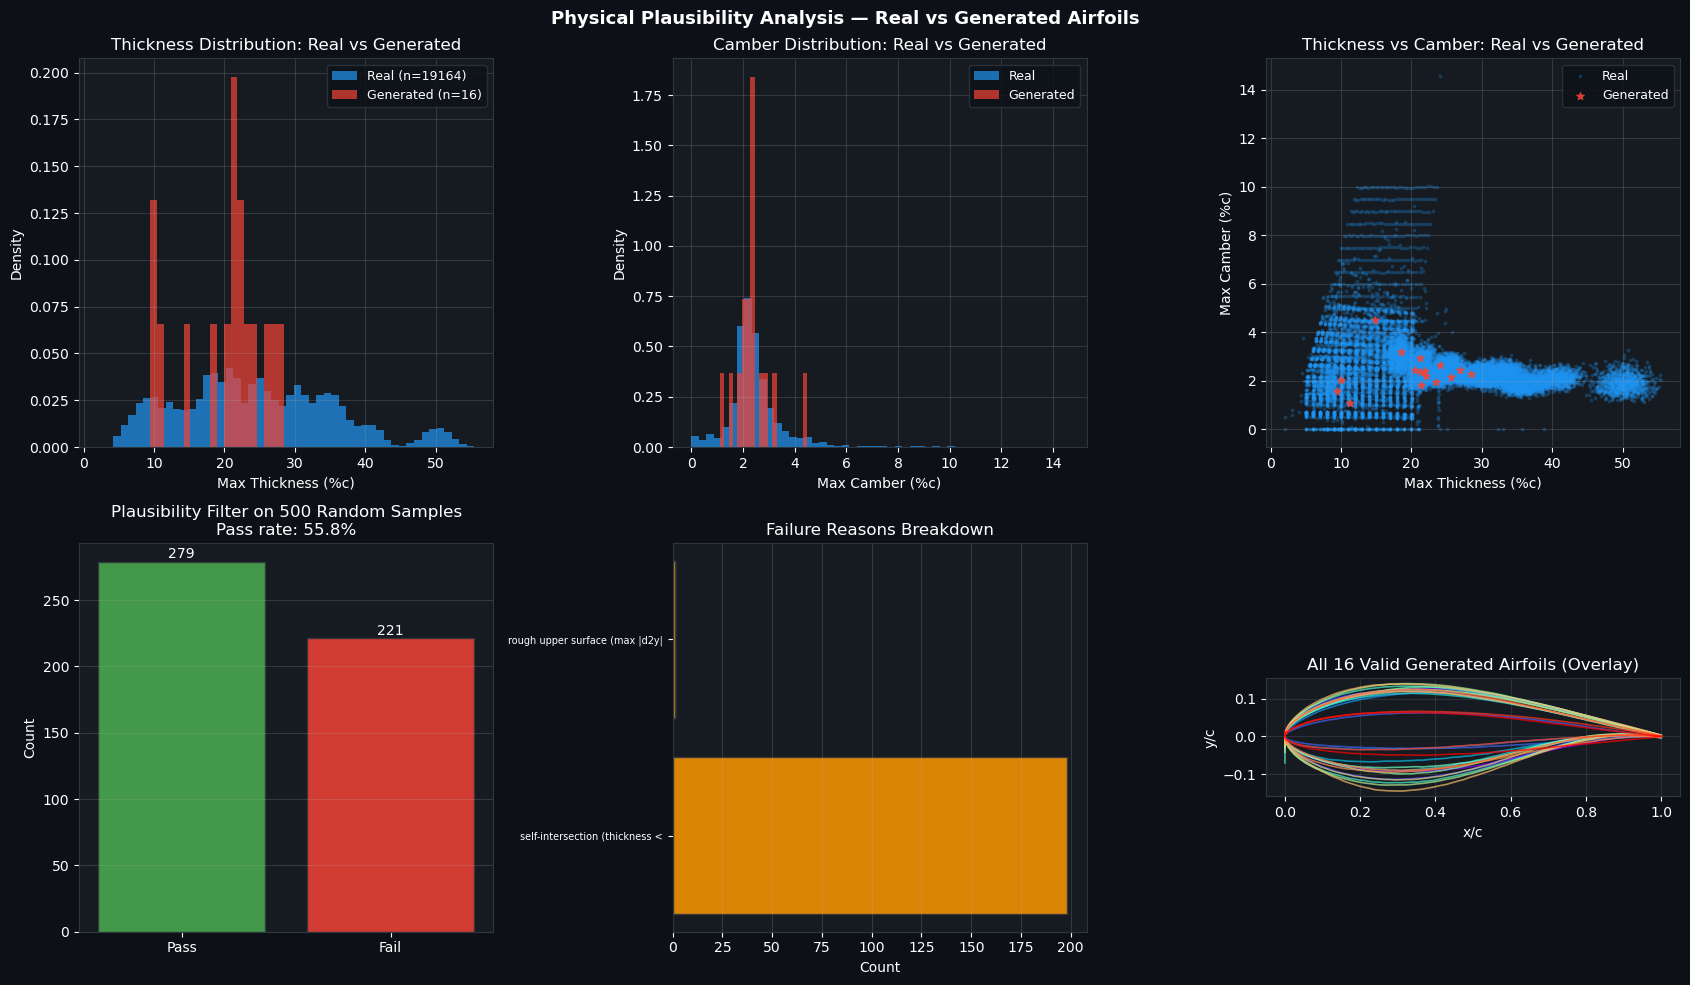

In [47]:
# ── Fig VAE-6 : Physical Plausibility Analysis ────────────────────────────
# Compare geometry statistics: real vs generated
from collections import Counter
gen_t   = np.array([(v[:N_POINTS] - v[N_POINTS:]).max() for v in generated_orig])
gen_c   = np.array([((v[:N_POINTS] + v[N_POINTS:]) / 2).max() for v in generated_orig])
 
# Also run on a larger set of random samples for the rejection analysis
n_large = 500
with torch.no_grad():
    z_large   = torch.randn(n_large, LATENT_DIM, device=device)
    x_large_t = model.decode(z_large).squeeze(1).cpu().numpy()
pass_mask = []
fail_reasons_all = []
for i in range(n_large):
    ok, reasons = check_plausibility(x_large_t[i])
    pass_mask.append(ok)
    fail_reasons_all.extend(reasons)
pass_mask = np.array(pass_mask)
fail_counts = Counter(fail_reasons_all)
 
fig6, axes = dark_fig(2, 3, (17, 10),
    "Physical Plausibility Analysis — Real vs Generated Airfoils")
 
# Thickness distribution comparison
axes[0, 0].hist(max_t_arr * 100, bins=50, alpha=0.7, color=C1,
                density=True, label=f"Real (n={len(max_t_arr)})")
if len(gen_t) > 0:
    axes[0, 0].hist(gen_t * 100, bins=20, alpha=0.7, color=C2,
                    density=True, label=f"Generated (n={len(gen_t)})")
axes[0, 0].set_xlabel("Max Thickness (%c)"); axes[0, 0].set_ylabel("Density")
axes[0, 0].set_title("Thickness Distribution: Real vs Generated")
axes[0, 0].legend(facecolor=DARK, edgecolor=BORDER, labelcolor="white", fontsize=9)
axes[0, 0].grid(alpha=0.2)
 
# Camber distribution comparison
axes[0, 1].hist(max_c_arr * 100, bins=50, alpha=0.7, color=C1,
                density=True, label="Real")
if len(gen_c) > 0:
    axes[0, 1].hist(gen_c * 100, bins=20, alpha=0.7, color=C2,
                    density=True, label="Generated")
axes[0, 1].set_xlabel("Max Camber (%c)"); axes[0, 1].set_ylabel("Density")
axes[0, 1].set_title("Camber Distribution: Real vs Generated")
axes[0, 1].legend(facecolor=DARK, edgecolor=BORDER, labelcolor="white", fontsize=9)
axes[0, 1].grid(alpha=0.2)
 
# Scatter: thickness vs camber real vs generated
axes[0, 2].scatter(max_t_arr * 100, max_c_arr * 100,
                    color=C1, alpha=0.2, s=3, label="Real")
if len(gen_t) > 0:
    axes[0, 2].scatter(gen_t * 100, gen_c * 100,
                        color=C2, alpha=0.8, s=30, marker="*", label="Generated",
                        zorder=5)
axes[0, 2].set_xlabel("Max Thickness (%c)"); axes[0, 2].set_ylabel("Max Camber (%c)")
axes[0, 2].set_title("Thickness vs Camber: Real vs Generated")
axes[0, 2].legend(facecolor=DARK, edgecolor=BORDER, labelcolor="white", fontsize=9)
axes[0, 2].grid(alpha=0.2)
 
# Pass/fail rate bar
labels_pf = ["Pass", "Fail"]
counts_pf = [pass_mask.sum(), (~pass_mask).sum()]
axes[1, 0].bar(labels_pf, counts_pf, color=[C3, C2], alpha=0.85, edgecolor=BORDER)
axes[1, 0].set_ylabel("Count"); axes[1, 0].set_title(
    f"Plausibility Filter on {n_large} Random Samples\nPass rate: {pass_mask.mean()*100:.1f}%")
for bar, cnt in zip(axes[1, 0].patches, counts_pf):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                     str(cnt), ha="center", color="white", fontsize=10)
axes[1, 0].grid(alpha=0.2, axis="y")
 
# Failure reason breakdown
if fail_counts:
    fr_labels = [r[:30] for r in list(fail_counts.keys())[:6]]
    fr_vals   = list(fail_counts.values())[:6]
    bars = axes[1, 1].barh(fr_labels, fr_vals, color=C4, alpha=0.85, edgecolor=BORDER)
    axes[1, 1].set_xlabel("Count")
    axes[1, 1].set_title("Failure Reasons Breakdown")
    axes[1, 1].grid(alpha=0.2, axis="x")
    for ax_t in axes[1, 1].yaxis.get_ticklabels():
        ax_t.set_color("white")
        ax_t.set_fontsize(7)
 
# Overlay of all valid generated airfoils
ax_ov = axes[1, 2]
ax_ov.set_facecolor(PANEL)
gen_rainbow = plt.cm.rainbow(np.linspace(0, 1, len(generated_valid)))
for vec, col in zip(generated_orig, gen_rainbow):
    draw_airfoil(ax_ov, vec, col, lw=1.2, alpha=0.7)
ax_ov.set_xlabel("x/c"); ax_ov.set_ylabel("y/c")
ax_ov.set_title(f"All {len(generated_valid)} Valid Generated Airfoils (Overlay)")
ax_ov.set_xlim(-0.05, 1.05); ax_ov.set_aspect("equal")
ax_ov.grid(alpha=0.15)
 
plt.tight_layout()
plt.show()